**Questions:**
1. How many customers visited each day? Are there any peak hours?
2. How many pizzas are typically included in one order? Are there any best-selling items?
3. How much revenue did the pizza chain generate this year? Are there any seasonal trends?
4. Are there any pizzas that can be optimized, or promotions that could be leveraged to improve sales?

For this assignment, I'm using the available dataset in Kaggle (https://www.kaggle.com/datasets/shilongzhuang/pizza-sales) to analyse the sales data.

**Importing libraries**

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from collections import Counter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D



**Reading the excel file using pandas library**

In [34]:
df = pd.read_excel('Data Model - Pizza Sales.xlsx', engine='openpyxl')

Before proceed to data analysis, we have to observe the available data headers/variables to decide the method to study the sales trend.

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_details_id   48620 non-null  int64         
 1   order_id           48620 non-null  int64         
 2   pizza_id           48620 non-null  object        
 3   quantity           48620 non-null  int64         
 4   order_date         48620 non-null  datetime64[ns]
 5   order_time         48620 non-null  object        
 6   unit_price         48620 non-null  float64       
 7   total_price        48620 non-null  float64       
 8   pizza_size         48620 non-null  object        
 9   pizza_category     48620 non-null  object        
 10  pizza_ingredients  48620 non-null  object        
 11  pizza_name         48620 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(6)
memory usage: 4.5+ MB


**The available headers and their description as per below:**
1. order_id: Unique identifier for each order placed by a table

2. order_details_id: Unique identifier for each pizza placed within each order (pizzas of the same type and size are kept in the same row, and the quantity increases)

3. pizza_id: Unique key identifier that ties the pizza ordered to its details, like size and price

4. quantity: Quantity ordered for each pizza of the same type and size

5. order_date: Date the order was placed (entered into the system prior to cooking & serving)

6. order_time: Time the order was placed (entered into the system prior to cooking & serving)

7. unit_price: Price of the pizza in USD

8. total_price: unit_price * quantity

9. pizza_size: Size of the pizza (Small, Medium, Large, X Large, or XX Large)

10. pizza_type: Unique key identifier that ties the pizza ordered to its details, like size and price

11. pizza_ingredients: ingredients used in the pizza as shown in the menu (they all include Mozzarella Cheese, even if not specified; and they all include Tomato Sauce, unless another sauce is specified)

12. pizza_name: Name of the pizza as shown in the menu

**Question 1:How many customers visited each day? Are there any peak hours?**

The amount of customers visit can be traced by creating a new data frame that is dropping the duplicate unique order_id and inserting new column of datetime for a more proper analysis

In [36]:
'''Create a new DataFrame called orders by dropping duplicate
entries based on the order_id column.'''

orders = df.drop_duplicates('order_id').copy()    

'''Combined date and time of order into a single date time column by 
concatenating the order_date and order_time columns, then converted to 
datetime format. eg 2015-01-01 11:38:36'''

orders['datetime'] = pd.to_datetime(
orders['order_date'].astype(str) + ' ' + orders['order_time'].astype(str)
)

'''Access the date and hour from datetime column and create new columns
of date and hour.'''
orders['date'] = orders['datetime'].dt.date
orders['hour'] = orders['datetime'].dt.hour


**A graph of "Time Series of Daily Customer Visits" is plotted with average of 59.6 order per day**

/opt/anaconda3/envs/peanuts/lib/python3.13/site-packages/pandas/plotting/_matplotlib/core.py:997: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


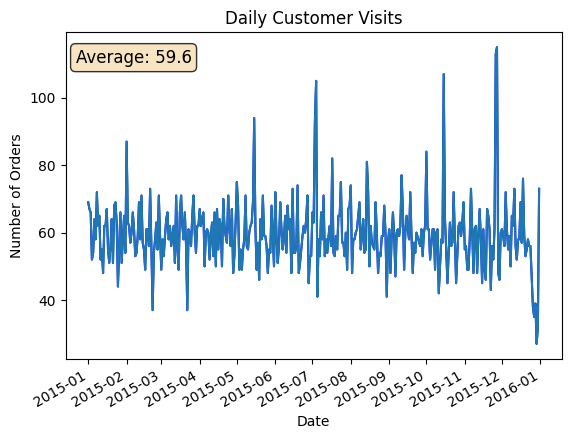

In [37]:
'''Group the orders DataFrame by date and count the unique order_id values
to get the number of orders per day.'''
daily_orders = orders.groupby('date')['order_id'].nunique()

'''Convert the index of daily_orders (which is currently a string) to proper datetime 
format for time series plotting.'''
daily_orders.index = pd.to_datetime(daily_orders.index)

'''Plot the daily orders as a line chart with proper date formatting on the x-axis.'''
plt.figure()
plt.plot(daily_orders.index, daily_orders.values, color='b')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

daily_orders.plot(kind='line')

average_orders = daily_orders.mean()
plt.text(0.02, 0.95, f'Average: {average_orders:.1f}', transform=plt.gca().transAxes, fontsize=12, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.title('Daily Customer Visits')

plt.show()




**Bar Chart for Number of Orders according to Day of Week with thursday until saturday has the highest number of order**

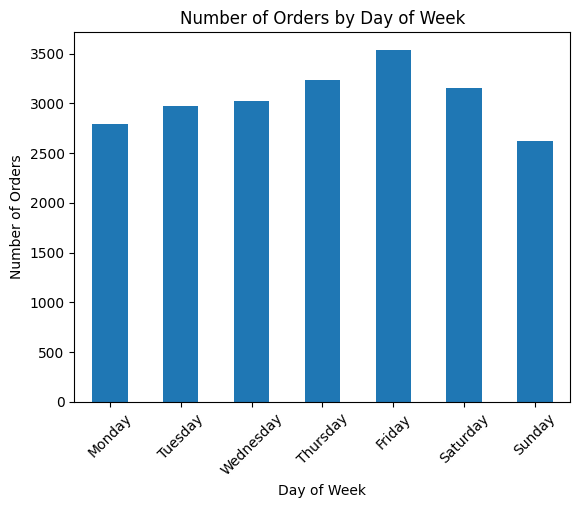

In [38]:
orders['weekday'] = orders['datetime'].dt.day_name()

weekday_orders = orders.groupby('weekday')['order_id'].nunique()

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_orders = weekday_orders.reindex(order)

plt.figure()
weekday_orders.plot(kind='bar')

plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.title('Number of Orders by Day of Week')
plt.xticks(rotation=45)

plt.show()

**Bar chart of "Hourly Order Distribution" is being plotted to observe the Top 5 hours that sells most pizzas**

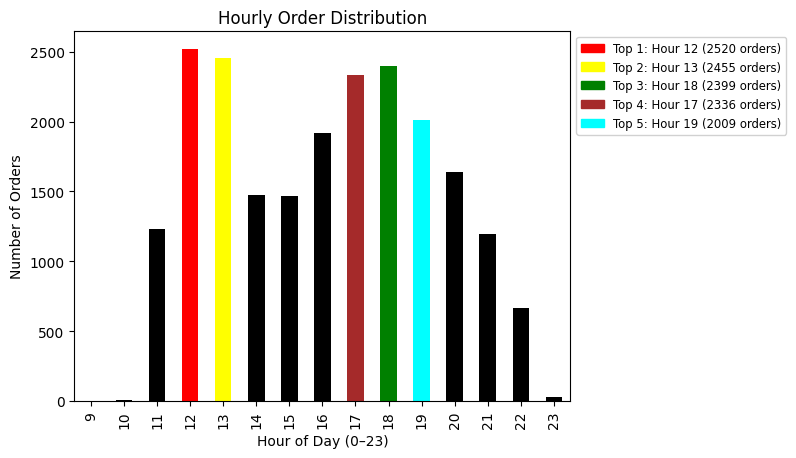

In [39]:
'''Group the orders DataFrame by hour and count the unique order_id values to get the number 
of orders per hour.'''
hourly_orders = orders.groupby('hour')['order_id'].nunique()

'''Identify the top 5 hours with the highest number of orders.'''
top5 = hourly_orders.sort_values(ascending=False).head(5)


colors = ['black'] * len(hourly_orders)

top_colors = ['red', 'yellow', 'green', 'brown', 'cyan']

for i, (hour, _) in enumerate(top5.items()):
    idx = hourly_orders.index.get_loc(hour)
    colors[idx] = top_colors[i]

handles = [Patch(color='red', label=f"Top 1: Hour {top5.index[0]} ({top5.iloc[0]} orders)"),
           Patch(color='yellow', label=f"Top 2: Hour {top5.index[1]} ({top5.iloc[1]} orders)"),
           Patch(color='green', label=f"Top 3: Hour {top5.index[2]} ({top5.iloc[2]} orders)"),
           Patch(color='brown', label=f"Top 4: Hour {top5.index[3]} ({top5.iloc[3]} orders)"),
           Patch(color='cyan', label=f"Top 5: Hour {top5.index[4]} ({top5.iloc[4]} orders)")]

plt.figure()
hourly_orders.plot(kind='bar', color=colors)

plt.legend(handles=handles, loc='upper left', bbox_to_anchor=(1, 1), fontsize='small', framealpha=0.9)   

plt.xlabel('Hour of Day (0–23)')
plt.ylabel('Number of Orders')
plt.title('Hourly Order Distribution')

plt.show()

Based on the Top 5 hours from bar chart, we can conclude that the peak hours are during lunch and dinner time.

**Question 2: How many pizzas are typically included in one order? Are there any best-selling items?**

**The histogram of "Number of Pizzas per Order" is being plotted**

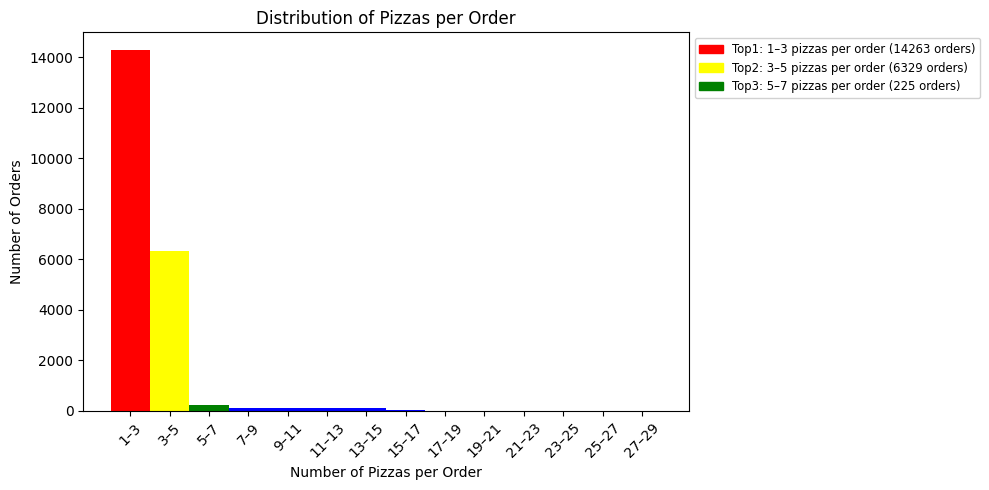

In [40]:
from matplotlib.patches import Patch

'''Compute the total number of pizzas per order by grouping the original dataframe by
order_id and summing the quantity column.'''
pizzas_per_order = df.groupby('order_id')['quantity'].sum()

'''Determine the maximum number of pizzas in any single order to set the range for binning.'''
max_val = pizzas_per_order.max()
bins = np.arange(1, max_val + 2, 2)
binned = pd.cut(pizzas_per_order, bins=bins, right=False)


counts = binned.value_counts().sort_index()

'''Top 3 bins with highest number of orders.'''
top3 = counts.sort_values(ascending=False).head(3)

colors = ['blue'] * len(counts)

top_colors = ['red', 'yellow', 'green']
for i, (interval, _) in enumerate(top3.items()):
    idx = counts.index.get_loc(interval)
    colors[idx] = top_colors[i]

plt.figure(figsize=(10,5))

plt.bar(range(len(counts)), counts.values, width=1.0,color=colors)

labels = [f"{int(interval.left)}–{int(interval.right)}"
          for interval in counts.index]

plt.xticks(range(len(labels)), labels, rotation=45)


handles = [Patch(color=top_colors[i],label=f"Top{i+1}: {int(interval.left)}–{int(interval.right)} pizzas per order ({count} orders)")
    for i, (interval, count) in enumerate(top3.items())
]

plt.legend(handles=handles, loc='upper left', bbox_to_anchor=(1, 1), fontsize='small', framealpha=0.9)

plt.xlabel('Number of Pizzas per Order')
plt.ylabel('Number of Orders')
plt.title('Distribution of Pizzas per Order')

plt.tight_layout()
plt.show()


**Top 10 Best Selling Pizzas by quantity** 

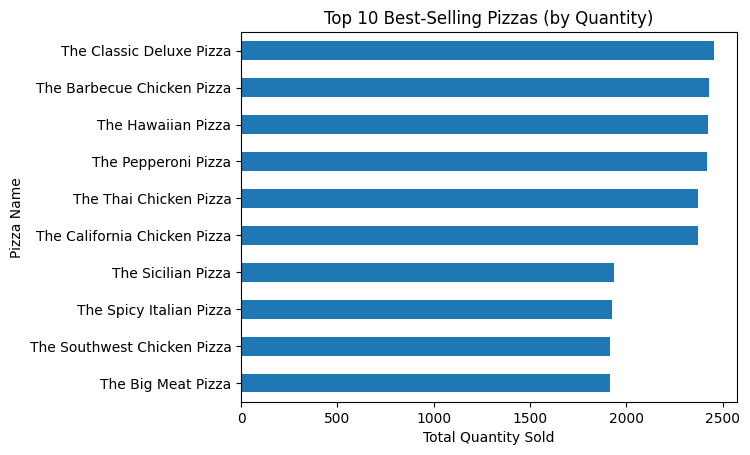

In [41]:
top_pizzas = df.groupby('pizza_name')['quantity'].sum().sort_values(ascending=False).head(10)
plt.figure()

top_pizzas.plot(kind='barh')

plt.xlabel('Total Quantity Sold')
plt.ylabel('Pizza Name')
plt.title('Top 10 Best-Selling Pizzas (by Quantity)')

plt.gca().invert_yaxis()
plt.show()

**Top 10 Pizzas by Revenue**

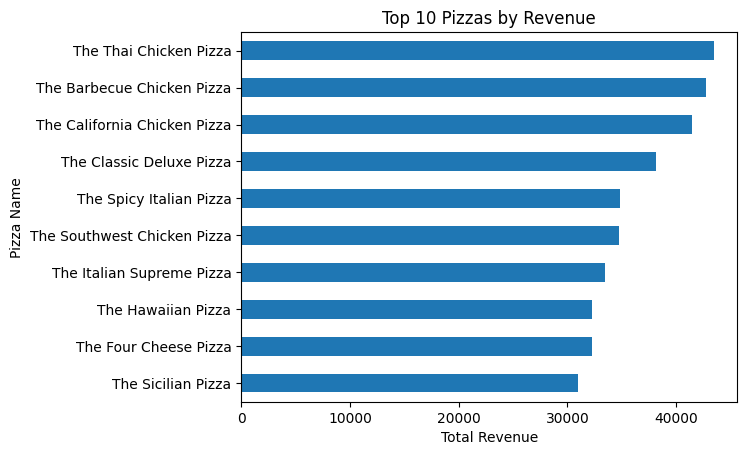

In [42]:
df['revenue'] = df['quantity'] * df['unit_price']

top_revenue = df.groupby('pizza_name')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure()

top_revenue.plot(kind='barh')

plt.xlabel('Total Revenue')
plt.ylabel('Pizza Name')
plt.title('Top 10 Pizzas by Revenue')

plt.gca().invert_yaxis()
plt.show()

**Question 3: How much revenue did the pizza chain generate this year? Are there any seasonal trends**

**Time series of Monthly revenue plot is being plotted to observe seasonal trend and annual revenue** 

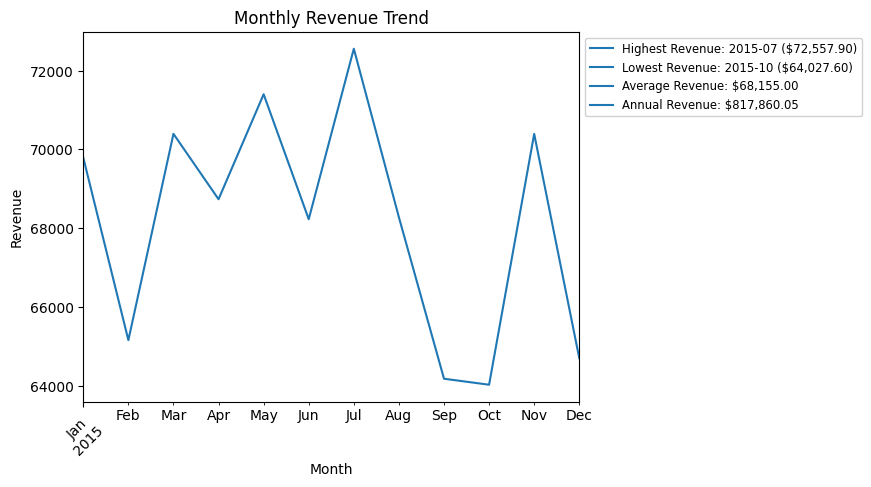

In [43]:
'''Calculate total revenue by multiplying quantity and unit_price, then summing the revenue column.'''
df['revenue'] = df['quantity'] * df['unit_price']

'''Calculate total revenue by summing the revenue column.'''
total_revenue = df['revenue'].sum()

'''Combine order_date and order_time into a single datetime column, then extract the month for grouping.'''
df['datetime'] = pd.to_datetime(

    df['order_date'].astype(str) + ' ' + df['order_time'].astype(str)

)
df['month'] = df['datetime'].dt.to_period('M')

monthly_revenue = df.groupby('month')['revenue'].sum()

'''Calculate average monthly revenue.'''
avg_value = monthly_revenue.mean()

'''Identify the month with the highest and lowest revenue.'''
highest_month = monthly_revenue.idxmax()
highest_value = monthly_revenue.max()

lowest_month = monthly_revenue.idxmin()
lowest_value = monthly_revenue.min()

plt.figure()

monthly_revenue.plot(kind='line')
handles = [Line2D([0], [0],label=f'Highest Revenue: {highest_month} (${highest_value:,.2f})'), 
           Line2D([0], [0],label=f'Lowest Revenue: {lowest_month} (${lowest_value:,.2f})'),
           Line2D([0], [0],label=f'Average Revenue: ${avg_value:,.2f}'),
           Line2D([0], [0],label=f'Annual Revenue: ${total_revenue:,.2f}')]

plt.legend(handles=handles, loc='upper left', bbox_to_anchor=(1, 1), fontsize='small', framealpha=0.9)

df['revenue'] = df['quantity'] * df['unit_price']
total_revenue = df['revenue'].sum()

plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Monthly Revenue Trend')

plt.xticks(rotation=45)
plt.show()

**Question 4: Are there any pizzas that can be optimized, or promotions that could be leveraged to improve sales?**

**Identify the low performing pizza in term of quantity being sold and revenue through scatter plot and average price per unit**

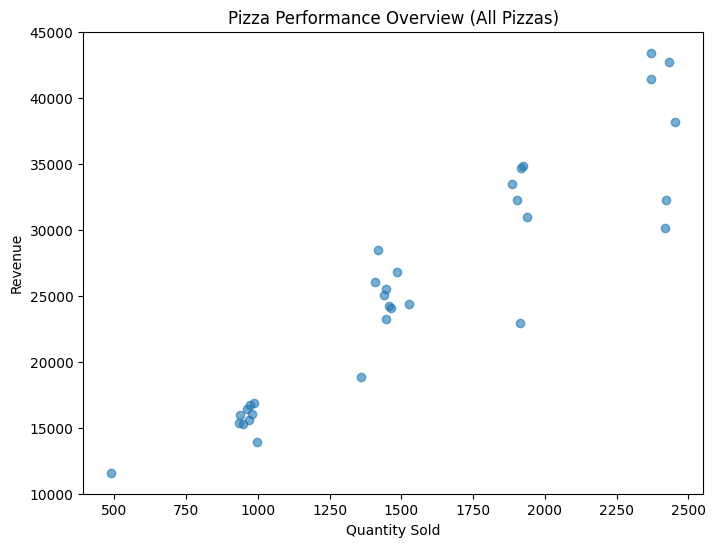

,quantity,revenue,avg_price_per_unit
pizza_name,,,
The Barbecue Chicken Pizza,2432,42768.00,17.585526
The Big Meat Pizza,1914,22968.00,12.000000
The Brie Carre Pizza,490,11588.50,23.650000
The Calabrese Pizza,937,15934.25,17.005603
The California Chicken Pizza,2370,41409.50,17.472363
The Chicken Alfredo Pizza,987,16900.25,17.122847
The Chicken Pesto Pizza,973,16701.75,17.165211
The Classic Deluxe Pizza,2453,38180.50,15.564819
The Five Cheese Pizza,1409,26066.50,18.500000


In [44]:
'''Group the original df by pizza_name and aggregate the total quantity and revenue for each pizza.'''
pizza_stats = df.groupby('pizza_name').agg({
    'quantity': 'sum',
    'revenue': 'sum'
})

'''Calculate the average price per unit for each pizza by dividing total revenue by total quantity.'''
pizza_stats['avg_price_per_unit'] = pizza_stats['revenue'] / pizza_stats['quantity']


plt.figure(figsize=(8,6))
plt.scatter(pizza_stats['quantity'], pizza_stats['revenue'], alpha=0.6)
plt.xlabel('Quantity Sold')
plt.ylabel('Revenue')
plt.title('Pizza Performance Overview (All Pizzas)')
plt.show()

pizza_stats

**The scatter plot shows a cluster of low performing pizzas on the bottom left of scatter plot. We can classify low performing pizzas by condition of: Quantity sold < 1500, generated revenue: < 20000, average price per unit < $17**

In [45]:
'''Identify low perfomer pizzas based on having quantity less than 1500 and revenue less than $20,000.'''
low_performers = pizza_stats[(pizza_stats['quantity'] < 1500) &(pizza_stats['revenue'] < 20000) 
                             & (pizza_stats['avg_price_per_unit'] < 17)]
low_performers 

,quantity,revenue,avg_price_per_unit
pizza_name,,,
The Green Garden Pizza,997,13955.75,13.997743
The Italian Vegetables Pizza,981,16019.25,16.329511
The Mediterranean Pizza,934,15360.50,16.445931
"The Pepperoni, Mushroom, and Peppers Pizza",1359,18834.50,13.859088
The Spinach Pesto Pizza,970,15596.00,16.078351
The Spinach Supreme Pizza,950,15277.75,16.081842


Those are the list of low performing pizzas which has been identified after filtering and have potential for promotional targeting.